
 # LOGISTICS ANALYSIS: 2026 FIFA WORLD CUP

This year, the largest-ever World Cup is being held simultaneously
across three host nations in North America.


# Host Countries:
1. USA
2. Canada
3. Mexico

Tournament Scale:
* Qualified teams - 48    Expanded from 32 for the first time in history
* Total matches - 104   Total number of matches across the tournament
* Host cities - 16    Distributed throughout the three host nations

# Analysis Scope: Focusing on the logistics for 7 selected national teams.


In [21]:
# Imports and Setup
import warnings
warnings.filterwarnings('ignore')

import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from geopy.distance import geodesic

from matplotlib.gridspec import GridSpec

from scipy import stats


# Data Loading



In [22]:
import os

DATA_DIR = os.getcwd() + os.sep
print(f"DATA_DIR = {DATA_DIR}")

def load_data(data_dir):

    tournament_stages = pd.read_csv(
        os.path.join(data_dir, 'tournament_stages.csv'),
        delimiter=',', encoding='ascii'
    )
    teams = pd.read_csv(
        os.path.join(data_dir, 'teams.csv'),
        delimiter=',', encoding='utf-8'
    )
    matches = pd.read_csv(
        os.path.join(data_dir, 'matches.csv'),
        delimiter=',', encoding='ascii'
    )
    host_cities = pd.read_csv(
        os.path.join(data_dir, 'host_cities.csv'),
        delimiter=',', encoding='ascii'
    )

    # Convert dates
    if 'kickoff_at' in matches.columns:
        matches['kickoff_at'] = pd.to_datetime(matches['kickoff_at'], errors='coerce')

    # Generations play off teams

    replacements = {
        'Winner UEFA Playoff A': 'Italy',
        'Winner UEFA Playoff B': 'Sweden',
        'Winner UEFA Playoff C': 'Turkey',
        'Winner UEFA Playoff D': 'Denmark',
        'Winner FIFA Playoff 1': 'DR Congo',
        'Winner FIFA Playoff 2': 'Bolivia'
    }
    teams['team_name'] = teams['team_name'].replace(replacements)


    print(f"   Teams: {len(teams)} | Plays: {len(matches)} | Citys: {len(host_cities)}")
    print(f"\n   Column in 'matches': {matches.columns.tolist()}")
    print(f"   Column in 'host_cities': {host_cities.columns.tolist()}")
    print(f"\n   Nu in 'matches':\n{matches.isnull().sum()}")

    return tournament_stages, teams, matches, host_cities

tournament_stages, teams, matches, host_cities = load_data(DATA_DIR)

DATA_DIR = /Users/mac/Documents/WB DSI/FIFAWorldCup2026project/
   Teams: 48 | Plays: 104 | Citys: 16

   Column in 'matches': ['id', 'match_number', 'home_team_id', 'away_team_id', 'city_id', 'stage_id', 'kickoff_at', 'match_label']
   Column in 'host_cities': ['id', 'city_name', 'country', 'venue_name', 'region_cluster', 'airport_code']

   Nu in 'matches':
id               0
match_number     0
home_team_id    32
away_team_id    32
city_id          0
stage_id         0
kickoff_at       0
match_label      0
dtype: int64


# Data Cleaning and Preprocessing

Let's inspect the datasets for possible cleaning tasks. We need to handle any type conversions, especially for date information in the matches dataset. The column `kickoff_at` is given as a string, so it might be beneficial to convert it to a datetime format to allow for time-based analyses.

In [23]:
# Quick inspection of datasets
print('Tournament Stages Columns:', tournament_stages.columns.tolist())
print('Teams Columns:', teams.columns.tolist())
print('Matches Columns:', matches.columns.tolist())
print('Host Cities Columns:', host_cities.columns.tolist())


# Check for null values in key datasets
print('Null values in tournament_stages:\n', tournament_stages.isnull().sum())
print('Null values in teams:\n', teams.isnull().sum())
print('Null values in matches:\n', matches.isnull().sum())
print('Null values in host_cities:\n', host_cities.isnull().sum())

Tournament Stages Columns: ['id', 'stage_name', 'stage_order']
Teams Columns: ['id', 'team_name', 'fifa_code', 'group_letter', 'is_placeholder']
Matches Columns: ['id', 'match_number', 'home_team_id', 'away_team_id', 'city_id', 'stage_id', 'kickoff_at', 'match_label']
Host Cities Columns: ['id', 'city_name', 'country', 'venue_name', 'region_cluster', 'airport_code']
Null values in tournament_stages:
 id             0
stage_name     0
stage_order    0
dtype: int64
Null values in teams:
 id                0
team_name         0
fifa_code         0
group_letter      0
is_placeholder    0
dtype: int64
Null values in matches:
 id               0
match_number     0
home_team_id    32
away_team_id    32
city_id          0
stage_id         0
kickoff_at       0
match_label      0
dtype: int64
Null values in host_cities:
 id                0
city_name         0
country           0
venue_name        0
region_cluster    0
airport_code      0
dtype: int64


## SECTION 1: HOST CITY GEO-COORDINATES (LAT, LON)

This section defines the geographical center of each tournament venue. Data is used for calculating travel distances and time zone transitions.

In [24]:
CITY_COORDS = {
    1:  (33.7490, -84.3880),   # Atlanta
    2:  (42.3601, -71.0589),   # Boston
    3:  (32.7767, -96.7970),   # Dallas
    4:  (29.7604, -95.3698),   # Houston
    5:  (39.0997, -94.5786),   # Kansas City
    6:  (34.0522, -118.2437),  # Los Angeles
    7:  (25.7617, -80.1918),   # Miami
    8:  (40.7128, -74.0060),   # New York
    9:  (39.9526, -75.1652),   # Philadelphia
    10: (37.7749, -122.4194),  # San Francisco
    11: (47.6062, -122.3321),  # Seattle
    12: (43.6532, -79.3832),   # Toronto
    13: (49.2827, -123.1207),  # Vancouver
    14: (20.6597, -103.3496),  # Guadalajara
    15: (19.4326, -99.1332),   # Mexico City
    16: (25.6866, -100.3161),  # Monterrey
}

# UTC time offset for each city (in hours)
CITY_UTC = {
    1: -5, 2: -5, 3: -6,  4: -6,  5: -6,
    6: -8, 7: -5, 8: -5,  9: -5, 10: -8,
    11: -8, 12: -5, 13: -8, 14: -6, 15: -6, 16: -6
}

CITY_NAMES = {
    1: 'Atlanta',       2: 'Boston',       3: 'Dallas',
    4: 'Houston',       5: 'Kansas City',  6: 'Los Angeles',
    7: 'Miami',         8: 'New York',     9: 'Philadelphia',
    10: 'San Francisco',11: 'Seattle',    12: 'Toronto',
    13: 'Vancouver',   14: 'Guadalajara', 15: 'Mexico City',
    16: 'Monterrey'
}


## SECTION 2: TEAM BASE CAMPS

This section tracks the official training hubs and living quarters for the participating national teams.

 Sources:
*    CONFIRMED - sportstravelmagazine.com (March 2026)
*    ESTIMATED - Estimated locations based on match-day geography
### Logistics Strategy:
Base camps are chosen to minimize travel fatigue across the 16 host cities in the USA, Canada, and Mexico.

In [25]:
BASE_CAMPS = {
    # CONFIRMED: Winston-Salem, NC (Wake Forest University + The Graylyn Estate)
    # Source: sportstravelmagazine.com - First nation to officially announce their base camp.
    # Logistics: Strategy covers East Coast + Central regions.
    # Scheduled Venues: Mexico City, New York, Dallas.
    'Germany': {
        'city':   'Winston-Salem, NC',
        'coords': (36.0999, -80.2442),
        'utc':    -5,  # Eastern Standard Time (EST)
        'status': 'CONFIRMED',
        'venues': ['Mexico City', 'New York', 'Dallas'],
    },

    # CONFIRMED: Frisco, Texas (FC Dallas Performance Center)
    # Source: sportstravelmagazine.com - Base camp for the UEFA Playoff Path B winner.
    # Logistics: Located in the Central Zone; ideal for cross-border transit.
    # Scheduled Venues: Dallas, Monterrey, Philadelphia.

    'Sweden': {
        'city':   'Frisco, TX',
        'coords': (33.1507, -96.8236),
        'utc':    -6,
        'status': 'CONFIRMED',
    },

    # CONFIRMED: Mansfield, Texas
    # Source: sportstravelmagazine.com - Base camp for the UEFA Playoff Path D winner.
    # Logistics: Strategic hub for Central and Eastern zone transitions.
    # Scheduled Venues: Guadalajara, Monterrey, Miami, Dallas.
    'Denmark': {
        'city':   'Mansfield, TX',
        'coords': (32.5632, -97.1417),
        'utc':    -6,
        'status': 'CONFIRMED',
    },

    # ESTIMATED: Charlotte, NC
    # Rationale: Centralized hub for East Coast fixtures (Miami, Philadelphia, Atlanta, Houston).
    # Charlotte is a FIFA-listed base camp city and offers superior connectivity
    # via CLT Airport (a major East Coast transit hub).

    'Italy': {
        'city':   'Charlotte, NC',
        'coords': (35.2271, -80.8431),
        'utc':    -5,
        'status': 'ESTIMATED (Matches: East Coast)',
    },

    # ESTIMATED: Los Angeles / Inglewood, CA
    # Rationale: Primary logistics hub for West Coast fixtures (Seattle, Los Angeles, Guadalajara).
    # The SoFi Stadium is a central tournament venue, and the region offers
    # world-class training infrastructure (e.g., LA Galaxy & LAFC facilities).
    'Turkey': {
        'city':   'Los Angeles, CA',
        'coords': (34.0522, -118.2437),
        'utc':    -8,
        'status': 'ESTIMATED (Matches: West Coast)',
    },

    # ESTIMATED: Oakland / Bay Area, CA
    # Rationale: Geographical midpoint for West Coast fixtures (LA, Vancouver, Seattle, SF).
    # Strategically positioned between Los Angeles and Vancouver with robust infrastructure.
    # Precedent: Australia has already confirmed Oakland (Soul Training Facility)
    # as their official base camp for these logistics.
    'DR Congo': {
        'city':   'Oakland, CA',
        'coords': (37.8044, -122.2712),
        'utc':    -8,
        'status': 'ESTIMATED: (MAtches: West Coast)',
    },

    # ESTIMATED Dallas, TX
    # Rationale: Central Zone fixtures (Dallas, Kansas City, Mexico City).
    # Strategic Advantage: Dallas hosts 2 out of 3 scheduled matches for this path.
    # Infrastructure: Features Frisco (a Dallas suburb) and the FC Dallas Toyota Stadium,
    # both of which are FIFA-listed elite training facilities.
    'Bolivia': {
        'city':   'Dallas, TX',
        'coords': (32.7767, -96.7970),
        'utc':    -6,
        'status': 'ESTIMATED (Matches: central Zone)',
    },
}

    # Origin Coordinates (Home Departure Points)

HOME_COORDS = {
    'Germany':  (52.5200,  13.4050),  # Berlin
    'Italy':    (41.9028,  12.4964),  # Rom
    'Sweden':   (59.3293,  18.0686),  # Stockholm
    'Turkey':   (39.9334,  32.8597),  # Ankara
    'Denmark':  (55.6761,  12.5683),  # Kopenhagen
    'DR Congo': (-4.4419,  15.2663),  # Kinshasa
    'Bolivia':  (-16.4897, -68.1193), # La Paz

}


HOME_UTC = {
    'Germany': 1, 'Italy': 1, 'Sweden': 1, 'Turkey': 3,
    'Denmark': 1, 'DR Congo': 1, 'Bolivia': -4,
}

## SECTION 3: JET LAG & CIRCADIAN DYSRHYTHMIA CALCULATION
Source: ECSS, Reilly et al. (2007) — Clinics in Sports Medicine

This section calculates the physiological impact of transmeridian travel.
Rule of Thumb: Each time zone crossed requires approximately 1 day of resynchronization for the circadian clock to realign.

In [26]:
def calculate_jetlag(tz_diff):
    """
Jet Lag Analysis: ECSS Protocol (Reilly et AL., 2007)
 Based on scientific recommendations from the European College of Sport Science.
 This model quantifies the recovery time required after transmeridian travel.

Recovery Rates:
   EASTWARD (tz_diff > 0): 1.0 day per time zone crossed.
   WESTWARD (tz_diff < 0): 0.5 days per time zone crossed.
Biological Rationale:
The human circadian rhythm has an intrinsic period of approximately 24.2 hours. Consequently, the body adapts more efficiently to a "lengthened" day (Westward travel / Phase Delay) than to a "shortened" day (Eastward travel / Phase Advance). """

    tz_crossed = abs(tz_diff)
    if tz_diff > 0:
        return tz_crossed * 1.0
    elif tz_diff < 0:
        return tz_crossed * 0.5
    return 0.0


## SECTION 4: HELPER FUNCTION - EXTRACTING TEAM MATCH DATA


In [27]:
def get_team_matches_from_csv(team_name, teams_df, matches_df):
    """
    Extract all match fixtures for a specific national team from the master tournament dataset (CSV).
    """
    team_row = teams_df[teams_df['team_name'] == team_name]
    if team_row.empty:
        return []

    team_id = team_row['id'].values[0]
    team_matches = matches_df[
        (matches_df['home_team_id'] == team_id) |
        (matches_df['away_team_id'] == team_id)
    ].sort_values('kickoff_at')

    results = []
    for _, row in team_matches.iterrows():
        if pd.notnull(row['kickoff_at']):
            if hasattr(row['kickoff_at'], 'strftime'):
                date_str = row['kickoff_at'].strftime('%Y-%m-%d')
            else:
                date_str = str(row['kickoff_at'])[:10]
            results.append((row['city_id'], date_str))

    return results



## SECTION 5: TRAVEL FATIGUE INDEX (TFI) CALCULATION

### Travel Logic:
1. Origin (Home) → Base Camp
2. [Base Camp → Stadium → Base Camp] × N Matches

### Scientific Formula (Recovery Days):
TFI_Days = (Distance_km / 1000 × 0.5) + Jet_Lag_Days + Recovery_Deficit
Components:
* Distance Impact: Every 1,000 km ≈ 0.5 days of physiological fatigue.
* Jet Lag: Calculated per ECSS Protocol (Reilly et al., 2007).
* Recovery Deficit: Penalty for schedule congestion (< 4 rest days).

### Rationale:
The model is based on European College of Sport Science (ECSS) guidelines for elite athlete performance during transmeridian travel.

NOTE: The return flight home after the final match is EXCLUDED.

In [28]:
def calculate_tfi(teams_list, teams_df, matches_df):
    """
    Calculates the cumulative Travel Fatigue Index (TFI) for a specific team.
    """
    results = []

    for team in teams_list:
        # Data availability safety check
        if team not in BASE_CAMPS or team not in HOME_COORDS:
            continue

        base    = BASE_CAMPS[team]
        home_c  = HOME_COORDS[team]
        home_tz = HOME_UTC[team]

        games = get_team_matches_from_csv(team, teams_df, matches_df)

        if not games:
            print(f"{team}: no matches found in csv — skipping")
            continue

        print(f" {team}: {len(games)} Matches found")

        total_km               = 0.0
        total_jetlag_days      = 0.0
        total_recovery_deficit = 0
        route_parts            = []

        #1: Home Country → Base
        total_km          += geodesic(home_c, base['coords']).kilometers
        total_jetlag_days += calculate_jetlag(base['utc'] - home_tz)
        route_parts.append(f"Home country→{base['city']}")

        prev_date = None


        seen_dates = set()
        for city_id, date_str in games:
            if city_id not in CITY_COORDS:
                continue

            curr_date      = datetime.datetime.strptime(date_str, '%Y-%m-%d')
            if date_str in seen_dates:
                continue
            seen_dates.add(date_str)
            stadium_coords = CITY_COORDS[city_id]
            stadium_tz     = CITY_UTC[city_id]

            # Base → Stadium
            total_km          += geodesic(base['coords'], stadium_coords).kilometers
            total_jetlag_days += calculate_jetlag(stadium_tz - base['utc'])

            # Stadium → Base
            total_km          += geodesic(stadium_coords, base['coords']).kilometers
            total_jetlag_days += calculate_jetlag(base['utc'] - stadium_tz)

            route_parts.append(CITY_NAMES.get(city_id, f"Stadt_{city_id}"))

            # Recovery Deficit
            # FIFA Standard: Minimum of 3 days between matches.
            # Deficit applies only if there are < 3 days of rest.
            if prev_date is not None:
                gap = (curr_date - prev_date).days
                if gap < 3:
                    total_recovery_deficit += (3 - gap)

            prev_date = curr_date

        # TFI in recovery days
        tfi_days = round(
            (total_km / 1000 * 0.5)
            + total_jetlag_days
            + total_recovery_deficit,
            1
        )

        results.append({
            'Team':             team,
            'Base_Camp':        base['city'],
            'Camp_Status':      base['status'],
            'Distance_km':      round(total_km, 0),
            'JetLag_Days':      round(total_jetlag_days, 1),
            'Recovery_Deficit': total_recovery_deficit,
            'TFI_Total':        tfi_days,
            'Matches':          len(games),
            'Route':            ' → '.join(route_parts),
        })
    return (
        pd.DataFrame(results)
        .sort_values('TFI_Total', ascending=False)
        .reset_index(drop=True)
    )

In [29]:
#  Visualization Functions
def plot_tfi_ranking(df):
    """ Horizontal bar chart - TFI Ranking in days."""
    fig, ax = plt.subplots(figsize=(15, 7))
    fig.patch.set_facecolor('#F0F4F8')
    ax.set_facecolor('#F0F4F8')

    # Ensure sorting matches the new column name
    sorted_df = df.sort_values('TFI_Total')

    # Risk-based coloring logic
    colors = ['#C0392B' if t > 25 else '#E67E22' if t > 15 else '#27AE60' for t in sorted_df['TFI_Total']]

    ylabels = [f"{row['Team']}\n({row['Base_Camp']})" for _, row in sorted_df.iterrows()]

    bars = ax.barh(ylabels, sorted_df['TFI_Total'], color=colors, alpha=0.88, height=0.55)

    for bar, val in zip(bars, sorted_df['TFI_Total']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val} Days', va='center', fontweight='bold')

    ax.set_title('Travel Fatigue Index — Recovery Days per Team', fontsize=15, fontweight='bold')
    ax.set_xlabel('Recovery Days')
    plt.tight_layout()
    plt.show()

def plot_tfi_components(df):
    """ Stacked bar - TFI Decomposition by component."""
    fig, ax = plt.subplots(figsize=(14, 7))
    fig.patch.set_facecolor('#F0F4F8')

    # Calculating distance component on the fly (0.5 days per 1000km)
    dist_days = df['Distance_km'] / 1000 * 0.5
    x = range(len(df))

    ax.bar(x, dist_days, label='Travel Distance', color='#3498DB', alpha=0.8)
    ax.bar(x, df['JetLag_Days'], bottom=dist_days, label='Jet Lag', color='#9B59B6', alpha=0.8)
    ax.bar(x, df['Recovery_Deficit'], bottom=dist_days + df['JetLag_Days'],
           label='Recovery Deficit', color='#E74C3C', alpha=0.8)

    ax.set_xticks(list(x))
    ax.set_xticklabels([row['Team'] for _, row in df.iterrows()], rotation=15)
    ax.set_title('TFI Components (Breakdown)', fontsize=15, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_jetlag_comparison(df):
    """ Jet Lag in days - Team comparison."""
    fig, ax = plt.subplots(figsize=(13, 5))
    fig.patch.set_facecolor('#F0F4F8')

    sorted_df = df.sort_values('JetLag_Days', ascending=False)
    xlabels = [f"{row['Team']}\n({row['Base_Camp']})" for _, row in sorted_df.iterrows()]

    bars = ax.bar(xlabels, sorted_df['JetLag_Days'], color='#E67E22', alpha=0.85)

    for bar, days in zip(bars, sorted_df['JetLag_Days']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f'{days} D.', ha='center', va='bottom', fontweight='bold')

    ax.set_title('Jet Lag Burden (ECSS Protocol)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Recovery Days (Jet Lag)')
    plt.tight_layout()
    plt.show()

def print_results(df):
    """Prints the formatted TFI results to the console."""
    print("\n" + "=" * 75)
    print("  TFI RESULTS OVERVIEW")
    print("=" * 75)
    # Using the new column names defined in your results.append()
    cols = [c for c in ["Team", "Base_Camp", "Camp_Status",
                        "Distance_km", "JetLag_Days", "Recovery_Deficit",
                        "TFI_Total", "Matches"] if c in df.columns]
    print(df[cols].to_string(index=False))
    print("=" * 75 + "\n")



 Calculating TFI (Travel Fatigue Index)...

 Germany: 3 Matches found
 Italy: 3 Matches found
 Sweden: 3 Matches found
 Turkey: 3 Matches found
 Denmark: 3 Matches found
 DR Congo: 3 Matches found
 Bolivia: 3 Matches found

  TFI RESULTS OVERVIEW
    Team         Base_Camp                       Camp_Status  Distance_km  JetLag_Days  Recovery_Deficit  TFI_Total  Matches
DR Congo       Oakland, CA  ESTIMATED: (MAtches: West Coast)      31749.0         15.0                 0       30.9        3
   Italy     Charlotte, NC   ESTIMATED (Matches: East Coast)      23816.0         12.0                 0       23.9        3
 Bolivia        Dallas, TX ESTIMATED (Matches: central Zone)      19302.0          5.5                 0       15.2        3
  Turkey   Los Angeles, CA   ESTIMATED (Matches: West Coast)      15889.0          5.5                 0       13.4        3
 Denmark     Mansfield, TX                         CONFIRMED      16431.0          5.0                 0       13.2        3
 G

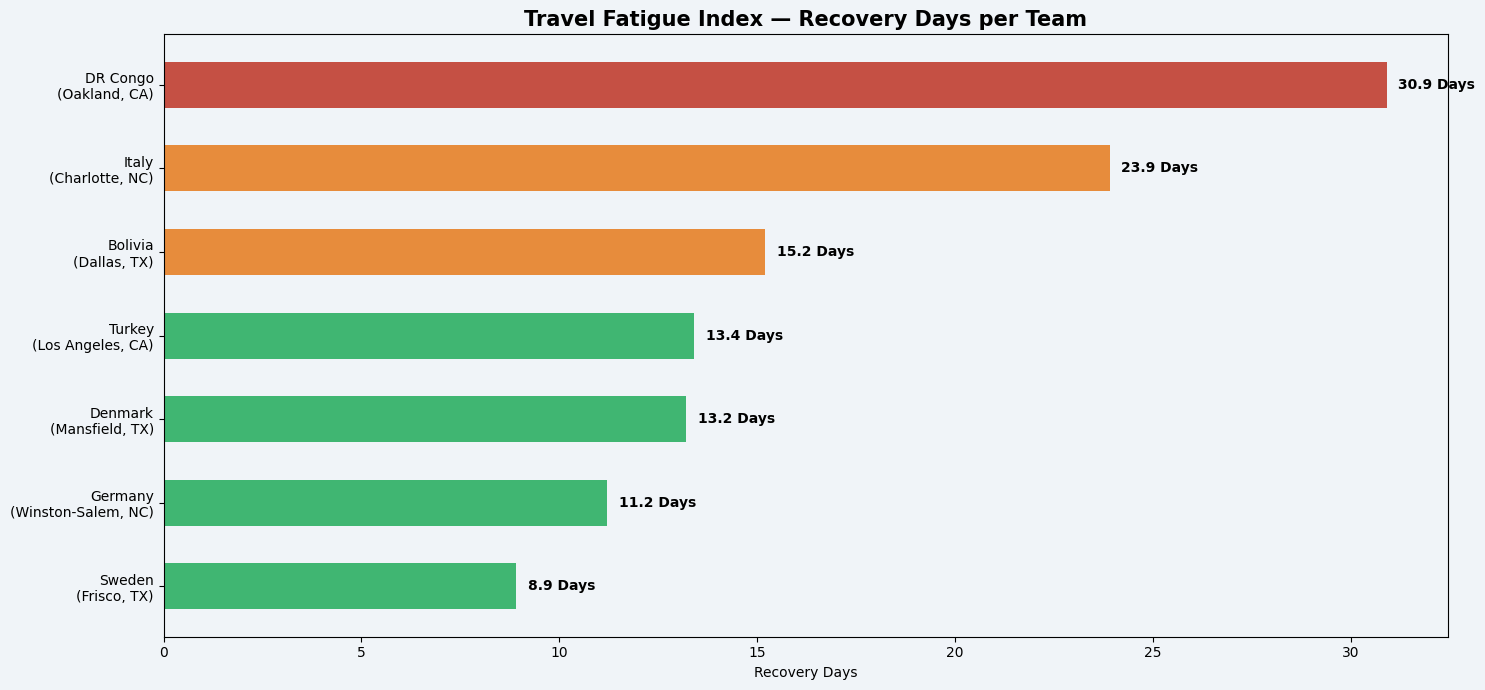

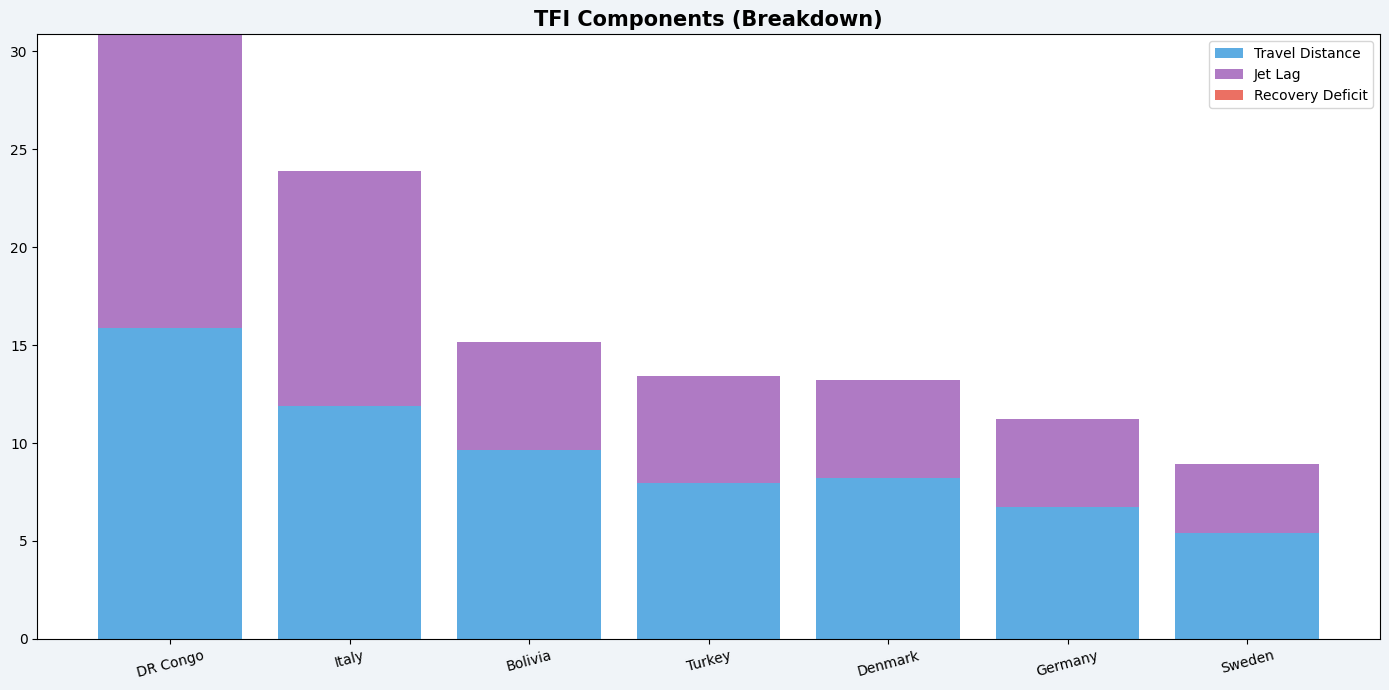

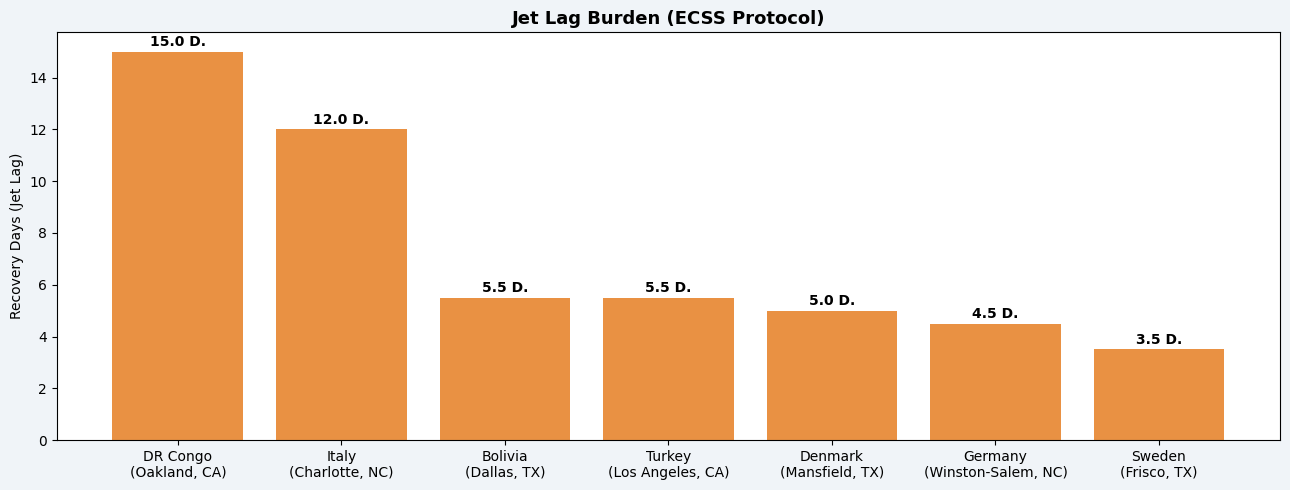

In [30]:
# Execution

TEAMS_LIST = ['Germany', 'Italy', 'Sweden', 'Turkey',
              'Denmark', 'DR Congo', 'Bolivia']

print("\n Calculating TFI (Travel Fatigue Index)...\n")
df_tfi = calculate_tfi(TEAMS_LIST, teams, matches)

# Output Results
print_results(df_tfi)

plot_tfi_ranking(df_tfi)
plot_tfi_components(df_tfi)
plot_jetlag_comparison(df_tfi)



## Data preparation (airports & logistics)

In [31]:
df_airports = matches.copy()
# Convert kickoff time to UTC date for logistical alignment
df_airports['date'] = pd.to_datetime(df_airports['kickoff_at'], utc=True).dt.date

# Merge with Host City data (Airport codes and Regional clusters)
df_airports = df_airports.merge(
    host_cities[['id', 'city_name', 'airport_code', 'region_cluster']],
    left_on='city_id', right_on='id', how='left'
)

# Total matches per airport (Logistical volume/throughput)
airport_total = (
    df_airports
    .groupby(['airport_code', 'city_name', 'region_cluster'])
    .size()
    .reset_index(name='total_matches')
    .sort_values('total_matches', ascending=False)
    .reset_index(drop=True)
)

# Peak Load Times - identifying critically short intervals (≤ 2 days)
peak_days = []
for airport, group in df_airports.groupby('airport_code'):
    dates = sorted(group['date'].unique())
    for i in range(len(dates) - 1):
        gap = (pd.Timestamp(dates[i+1]) - pd.Timestamp(dates[i])).days
        if gap <= 2:   # Focus on high-frequency operational phases
            peak_days.append({
                'airport_code':  airport,
                'city_name':     group['city_name'].iloc[0],
                'date_1':        dates[i],
                'date_2':        dates[i+1],
                'time_interval': gap
            })

df_peak = pd.DataFrame(peak_days) if peak_days else pd.DataFrame()

# Load distribution by Regional Clusters
region_load = (
    df_airports
    .groupby('region_cluster')
    .size()
    .reset_index(name='total_matches')
    .sort_values('total_matches', ascending=False)
)

print("Data preparation successful")
print(f"Airports: {len(airport_total)} | Peak Load Phases: {len(df_peak)}")

Data preparation successful
Airports: 16 | Peak Load Phases: 12


## Logistics summary output

In [32]:
line = "=" * 75
print(line)
print("AIRPORT LOAD ANALYSIS — SUMMARY".center(len(line)))
print(line)


print("\nMatches per Airport (Volume/Throughput):")
# Reflecting the updated English column names from the previous block
print(airport_total.to_string(index=False))

print("\nLoad by Regional Cluster:")
print(region_load.to_string(index=False))

print("\nPeak Load Phases (High-frequency windows: ≤ 2 days):")
if not df_peak.empty:
    print(df_peak.to_string(index=False))
    print(f"\n   Total number of peak load occurrences: {len(df_peak)}")
    print(f"   Affected cities: {', '.join(df_peak['city_name'].unique())}")
else:
    print("   No critical peak load windows identified.")

print("\n" + "=" * 75)

                      AIRPORT LOAD ANALYSIS — SUMMARY                      

Matches per Airport (Volume/Throughput):
airport_code              city_name region_cluster  total_matches
         DAL                 Dallas        Central              9
         ATL                Atlanta           East              8
         EWR    New York/New Jersey           East              8
         LAX            Los Angeles           West              8
         BOS                 Boston           East              7
         IAH                Houston        Central              7
         YVR              Vancouver           West              7
         MIA                  Miami           East              7
         SFO San Francisco Bay Area           West              6
         MCI            Kansas City        Central              6
         SEA                Seattle           West              6
         PHL           Philadelphia           East              6
         YYZ            

## Chart: Matches per Airport

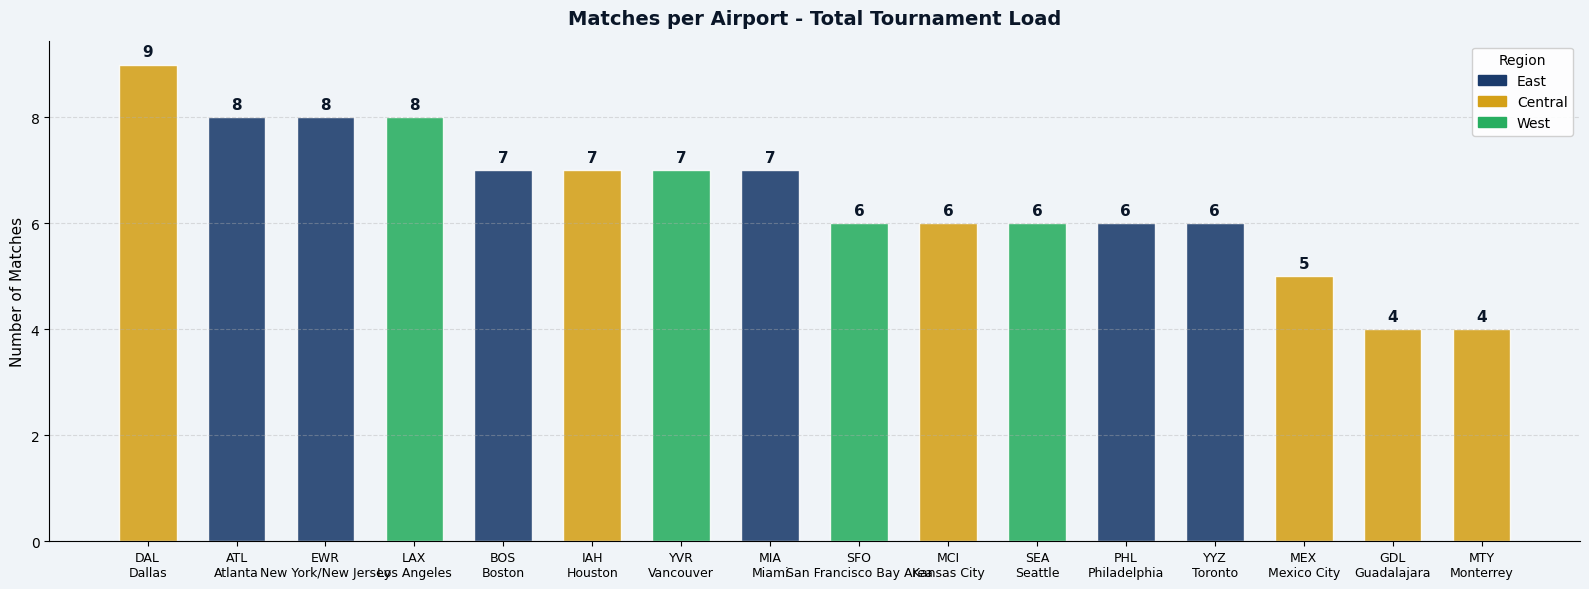

In [33]:
# Color scheme for regions
REGION_COLORS = {
    'East':    '#1A3A6B',
    'Central': '#D4A017',
    'West':    '#27AE60',
    'Mexico':  '#C0392B',
    'Canada':  '#8E44AD',
}

fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('#F0F4F8')
ax.set_facecolor('#F0F4F8')

# Bar colors based on the region cluster
# Note: Ensure 'region_cluster' and 'total_matches' reflect your new English keys
bar_colors = [REGION_COLORS.get(r, '#888') for r in airport_total['region_cluster']]
bars = ax.bar(range(len(airport_total)), airport_total['total_matches'],
              color=bar_colors, alpha=0.88, edgecolor='white', width=0.65)

# Display values above the bars
for bar, val in zip(bars, airport_total['total_matches']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            str(val), ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#0A1628')

# Label X-axis: Airport code and city name
ax.set_xticks(range(len(airport_total)))
ax.set_xticklabels(
    [f"{r['airport_code']}\n{r['city_name']}" for _, r in airport_total.iterrows()],
    fontsize=9
)

# Create legend
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in REGION_COLORS.items()
                  if k in airport_total['region_cluster'].values]
ax.legend(handles=legend_patches, title='Region', fontsize=10,
          loc='upper right', framealpha=0.9)

# Title and axis labeling
ax.set_title('Matches per Airport - Total Tournament Load',
             fontsize=14, fontweight='bold', color='#0A1628', pad=12)
ax.set_ylabel('Number of Matches', fontsize=11)

# Design optimization
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Chart: Match Distribution by Region

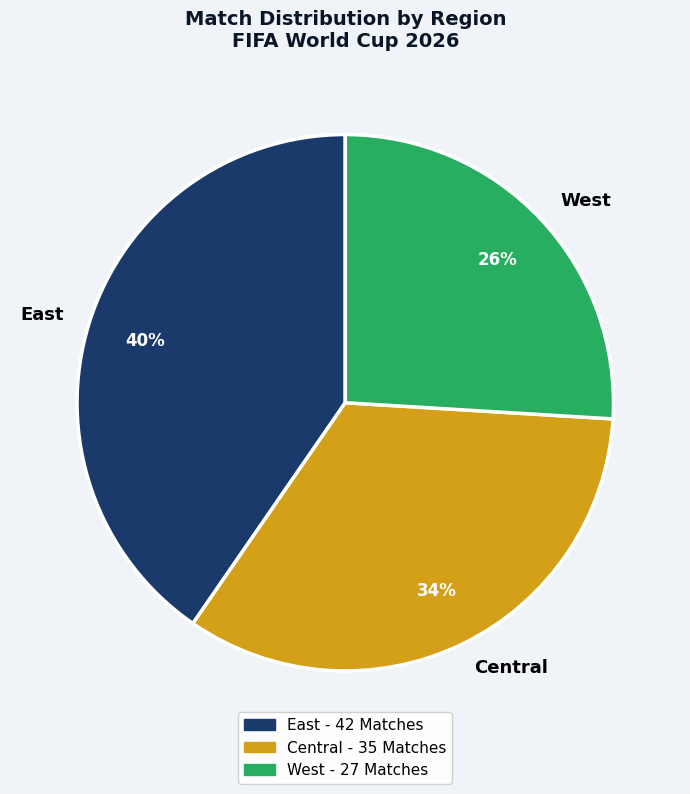

In [34]:
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor('#F0F4F8')

# Assign colors based on regional clusters
pie_colors = [REGION_COLORS.get(r, '#888') for r in region_load['region_cluster']]

# Create Pie Chart
wedges, texts, autotexts = ax.pie(
    region_load['total_matches'],  # Updated to English key
    labels=region_load['region_cluster'],
    colors=pie_colors,
    autopct='%1.0f%%',
    startangle=90,
    pctdistance=0.78,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5}
)

# Text styling for regions and percentages
for t in texts:
    t.set_fontsize(13)
    t.set_fontweight('bold')
for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight('bold')
    t.set_color('white') # Improved contrast for percentages

# Add absolute values to the legend labels
legend_labels = [f"{r['region_cluster']} - {r['total_matches']} Matches"
                 for _, r in region_load.iterrows()]

legend_patches = [mpatches.Patch(color=REGION_COLORS.get(r['region_cluster'], '#888'),
                                  label=legend_labels[i])
                  for i, (_, r) in enumerate(region_load.iterrows())]

# Position legend below the chart
ax.legend(handles=legend_patches, loc='lower center',
          bbox_to_anchor=(0.5, -0.08), fontsize=11, framealpha=0.9)

ax.set_title('Match Distribution by Region\nFIFA World Cup 2026',
             fontsize=14, fontweight='bold', color='#0A1628', pad=15)

plt.tight_layout()
# Save disabled
plt.show()

## Chart: Peak Load Phases (Operational Pressure)

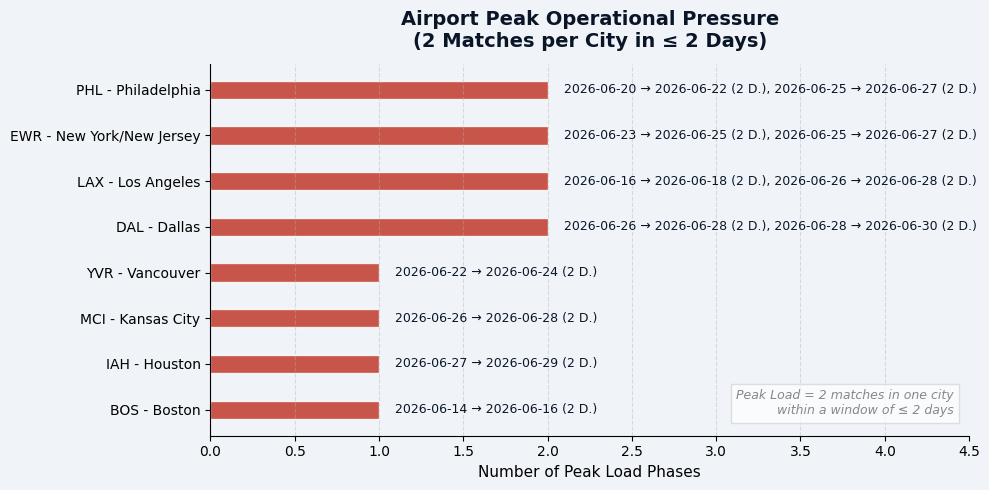

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#F0F4F8')
ax.set_facecolor('#F0F4F8')

if not df_peak.empty:
    # Group by city and airport to count the number of peak occurrences
    peak_count = (df_peak.groupby(['city_name', 'airport_code'])
                         .size()
                         .reset_index(name='peak_events')
                         .sort_values('peak_events'))

    bar_labels = [f"{r['airport_code']} - {r['city_name']}"
                  for _, r in peak_count.iterrows()]

    # Horizontal bars in warning color (Red)
    bars = ax.barh(bar_labels, peak_count['peak_events'],
                   color='#C0392B', alpha=0.85, edgecolor='white', height=0.4)

    # Display specific date details next to the bars
    for bar, val, (_, row) in zip(bars, peak_count['peak_events'], peak_count.iterrows()):
        # Find specific peaks for this airport
        city_peaks = df_peak[df_peak['airport_code'] == row['airport_code']]

        # Format date ranges (D. stands for Days)
        dates_str = ', '.join([f"{r['date_1']} → {r['date_2']} ({r['time_interval']} D.)"
                               for _, r in city_peaks.iterrows()])

        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
                f"  {dates_str}",
                va='center', fontsize=9, color='#0A1628')

    ax.set_xlim(0, peak_count['peak_events'].max() + 2.5)
    ax.set_xlabel('Number of Peak Load Phases', fontsize=11)

    # Definition of a Peak Load (Info Box)
    ax.text(0.98, 0.05,
            'Peak Load = 2 matches in one city\nwithin a window of ≤ 2 days',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
            color='#888', style='italic',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='lightgray'))
else:
    # Display message if no critical phases were found
    ax.text(0.5, 0.5, 'No critical peak load windows identified.',
            ha='center', va='center', fontsize=13,
            color='#888', transform=ax.transAxes)

ax.set_title('Airport Peak Operational Pressure\n(2 Matches per City in ≤ 2 Days)',
             fontsize=14, fontweight='bold', color='#0A1628', pad=12)

# Design Adjustments
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## TFI analysis for WC 2022
All matches held in Qatar. TFI = (Distance / 1000 * 0.5) + Jet Lag


In [36]:
# Central coordinates for Doha (Stadium Cluster)
DOHA     = (25.2854, 51.5310)
DOHA_UTC = 3

# Home coordinates and UTC offsets of the 32 participating nations (WC 2022)
TEAM_HOME_2022 = {
    'Qatar':         ((25.2854,  51.5310),   3),
    'Ecuador':       ((-1.8312, -78.1834),  -5),
    'England':       ((51.5074,  -0.1278),   1),
    'Iran':          ((35.6892,  51.3890), 3.5),
    'Senegal':       ((14.7167, -17.4677),   0),
    'United States': ((38.8951, -77.0364),  -5),
    'Netherlands':   ((52.3676,   4.9041),   1),
    'Argentina':     ((-34.6037,-58.3816),  -3),
    'Denmark':       ((55.6761,  12.5683),   1),
    'Mexico':        ((19.4326, -99.1332),  -6),
    'France':        ((48.8566,   2.3522),   1),
    'Australia':     ((-35.2809,149.1300),  11),
    'Germany':       ((52.5200,  13.4050),   1),
    'Japan':         ((35.6762, 139.6503),   9),
    'Spain':         ((40.4168,  -3.7038),   1),
    'Costa Rica':    ((9.9281,  -84.0907),  -6),
    'Belgium':       ((50.8503,   4.3517),   1),
    'Morocco':       ((33.9716,  -6.8498),   1),
    'Croatia':       ((45.8150,  15.9819),   1),
    'Brazil':        ((-15.7801,-47.9292),  -3),
    'Serbia':        ((44.7866,  20.4489),   1),
    'Switzerland':   ((46.9480,   7.4474),   1),
    'Cameroon':      ((3.8480,   11.5021),   1),
    'Portugal':      ((38.7223,  -9.1393),   1),
    'Ghana':         ((5.6037,   -0.1870),   0),
    'Uruguay':       ((-34.9011,-56.1915),  -3),
    'Korea Republic':((37.5665, 126.9780),   9),
    'Poland':        ((52.2297,  21.0122),   1),
    'Tunisia':       ((36.8190,  10.1658),   1),
    'Canada':        ((45.4215, -75.6972),  -5),
    'Wales':         ((51.4816,  -3.1791),   0),
    'Saudi Arabia':  ((24.6877,  46.7219),   3),
}

def calculate_jetlag_2022(tz_diff):
    """
    Calculates jet lag recovery days based on time difference.
    Eastward travel (positive) is weighted 1.0, Westward (negative) 0.5.
    """
    if tz_diff > 0:
        return tz_diff * 1.0    # Eastward flight
    if tz_diff < 0:
        return abs(tz_diff) * 0.5  # Westward flight
    return 0.0

# Data collection for TFI comparison
tfi_data_2022 = []

for team, (home_coords, home_utc) in TEAM_HOME_2022.items():
    # High-precision distance calculation (WGS-84) via Geopy
    distance_km = geodesic(home_coords, DOHA).kilometers

    # Calculate timezone difference
    jetlag_days = calculate_jetlag_2022(DOHA_UTC - home_utc)

    # TFI Formula (ECSS Standard: Reilly et al., 2007)
    # Includes travel fatigue and jet lag adaptation
    tfi_total = round((distance_km / 1000 * 0.5) + jetlag_days, 1)

    tfi_data_2022.append({
        'Team':          team,
        'Distance_km':   round(distance_km),
        'JetLag_Days':   round(jetlag_days, 1),
        'TFI_Total':     tfi_total,
    })

# Create DataFrame and sort (highest burden first)
df_tfi_2022 = (
    pd.DataFrame(tfi_data_2022)
    .sort_values('TFI_Total', ascending=False)
    .reset_index(drop=True)
)

# Console Output
WIDTH = 75
print("\n" + "=" * WIDTH)
print("  HISTORICAL TFI VALUES: FIFA WORLD CUP 2022 (QATAR)".center(WIDTH))
print("=" * WIDTH)
print(df_tfi_2022[['Team', 'Distance_km', 'JetLag_Days', 'TFI_Total']].to_string(index=False))
print("\nAnalysis for 2022 successfully completed.")


              HISTORICAL TFI VALUES: FIFA WORLD CUP 2022 (QATAR)           
          Team  Distance_km  JetLag_Days  TFI_Total
        Mexico        14134          9.0       16.1
    Costa Rica        13833          9.0       15.9
       Ecuador        14050          8.0       15.0
 United States        11120          8.0       13.6
        Canada        10536          8.0       13.3
     Argentina        13313          6.0       12.7
       Uruguay        13123          6.0       12.6
        Brazil        11681          6.0       11.8
     Australia        12242          4.0       10.1
         Japan         8260          3.0        7.1
Korea Republic         7114          3.0        6.6
       Senegal         7242          3.0        6.6
         Ghana         5917          3.0        6.0
         Wales         5426          3.0        5.7
      Portugal         5816          2.0        4.9
       Morocco         5661          2.0        4.8
         Spain         5343          2.

## Loading WC 2022 results and linking with TFI

In [37]:
WC2022_PATH = os.path.join(DATA_DIR, 'Fifa_world_cup_matches.csv')

# Load historical match data
df_wc2022 = pd.read_csv(WC2022_PATH)

# Calculate points and statistics per team
results_stats = {}
for _, row in df_wc2022.iterrows():
    t1 = row['team1'].strip().title()
    t2 = row['team2'].strip().title()
    g1 = int(row['number of goals team1'])
    g2 = int(row['number of goals team2'])
    is_group_stage = 'Group' in str(row['category'])

    for team, gf, ga in [(t1, g1, g2), (t2, g2, g1)]:
        if team not in results_stats:
            results_stats[team] = {
                'total_points': 0, 'group_points': 0,
                'goals_scored': 0, 'goals_conceded': 0,
                'wins': 0, 'draws': 0, 'losses': 0, 'matches_played': 0
            }
        results_stats[team]['goals_scored']    += gf
        results_stats[team]['goals_conceded']  += ga
        results_stats[team]['matches_played']  += 1

        if gf > ga:
            results_stats[team]['wins']         += 1
            results_stats[team]['total_points'] += 3
            if is_group_stage: results_stats[team]['group_points'] += 3
        elif gf == ga:
            results_stats[team]['draws']        += 1
            results_stats[team]['total_points'] += 1
            if is_group_stage: results_stats[team]['group_points'] += 1
        else:
            results_stats[team]['losses']       += 1

# Identification of teams that reached the Knockout Stage (Playoffs)
playoff_teams = set()
df_knockout = df_wc2022[~df_wc2022['category'].str.contains('Group', na=False)]
for _, row in df_knockout.iterrows():
    playoff_teams.add(row['team1'].strip().title())
    playoff_teams.add(row['team2'].strip().title())

# Create DataFrame from the results
df_results_2022 = pd.DataFrame(results_stats).T.reset_index()
df_results_2022.columns = ['Team'] + list(df_results_2022.columns[1:])

# Additional metrics: Qualification status and Goal Difference
df_results_2022['qualified_knockout'] = df_results_2022['Team'].apply(lambda t: 1 if t in playoff_teams else 0)
df_results_2022['goal_difference']    = df_results_2022['goals_scored'] - df_results_2022['goals_conceded']

# Merging TFI data and performance results (Normalization via Team_Key)
# Note: Using the English keys 'Team' and 'TFI_Total' from the previous step
df_tfi_2022['Team_Key']     = df_tfi_2022['Team'].str.upper()
df_results_2022['Team_Key'] = df_results_2022['Team'].str.upper()

df_merged_2022 = df_tfi_2022.merge(
    df_results_2022, on='Team_Key', how='inner', suffixes=('', '_res')
)

# Console Output for Validation
print(f"Mapping successful: {len(df_merged_2022)} out of {len(df_tfi_2022)} teams linked.")
print("\nOverview: TFI vs. Performance (Excerpt):")
cols_to_show = ['Team', 'TFI_Total', 'group_points', 'total_points', 'qualified_knockout']
print(df_merged_2022[cols_to_show].to_string(index=False))

Mapping successful: 32 out of 32 teams linked.

Overview: TFI vs. Performance (Excerpt):
          Team  TFI_Total  group_points  total_points  qualified_knockout
        Mexico       16.1             4             4                   0
    Costa Rica       15.9             3             3                   0
       Ecuador       15.0             4             4                   0
 United States       13.6             5             5                   1
        Canada       13.3             0             0                   0
     Argentina       12.7             6            14                   1
       Uruguay       12.6             4             4                   0
        Brazil       11.8             6            10                   1
     Australia       10.1             6             6                   1
         Japan        7.1             6             7                   1
Korea Republic        6.6             4             4                   1
       Senegal        6

## Statistical hypothesis test

In [38]:
WIDTH = 75
print("=" * WIDTH)
print("HYPOTHESIS: HIGH TFI → LOWER PERFORMANCE".center(WIDTH))
print("=" * WIDTH)

# 1. Correlation: TFI vs. Group Stage Points
# Using keys: 'TFI_Total' and 'group_points'
r1, p1 = stats.pearsonr(df_merged_2022['TFI_Total'], df_merged_2022['group_points'])
print(f"\n1. Correlation: TFI vs. Group Stage Points:")
significance1 = 'Statistically Significant' if p1 < 0.05 else 'Not Significant (p > 0.05)'
print(f"   r = {r1:.3f}  |  p-value = {p1:.3f}  ({significance1})")

# 2. Correlation: TFI vs. Goal Difference
r2, p2 = stats.pearsonr(df_merged_2022['TFI_Total'], df_merged_2022['goal_difference'])
print(f"\n2. Correlation: TFI vs. Goal Difference:")
significance2 = 'Statistically Significant' if p2 < 0.05 else 'Not Significant (p > 0.05)'
print(f"   r = {r2:.3f}  |  p-value = {p2:.3f}  ({significance2})")

# 3. Independent T-Test: TFI — Qualified vs. Eliminated
qualified = df_merged_2022[df_merged_2022['qualified_knockout'] == 1]['TFI_Total']
eliminated = df_merged_2022[df_merged_2022['qualified_knockout'] == 0]['TFI_Total']
t_stat, p_t = stats.ttest_ind(qualified, eliminated)

print(f"\n3. T-Test: TFI Comparison (Qualified vs. Eliminated):")
print(f"   Mean TFI (Qualified):  {qualified.mean():.1f}")
print(f"   Mean TFI (Eliminated): {eliminated.mean():.1f}")
significance_t = 'Statistically Significant' if p_t < 0.05 else 'Not Significant (p > 0.05)'
print(f"   t = {t_stat:.3f}  |  p-value = {p_t:.3f}  ({significance_t})")

# Final Conclusion
print("\n" + "-" * WIDTH)
if r1 < -0.2 and p1 < 0.05:
    conclusion = "Hypothesis supported"
elif r1 < 0:
    conclusion = "Weak negative correlation - Trend visible, but limited statistical power"
else:
    conclusion = "Hypothesis not supported"

print(f"  Conclusion: {conclusion}")
print(f"  An r-value of {r1:.3f} indicates: ", end="")

if abs(r1) > 0.5:   print("Strong relationship")
elif abs(r1) > 0.3: print("Moderate relationship")
else:               print("Weak relationship")
print("-" * WIDTH)

                  HYPOTHESIS: HIGH TFI → LOWER PERFORMANCE                 

1. Correlation: TFI vs. Group Stage Points:
   r = 0.087  |  p-value = 0.636  (Not Significant (p > 0.05))

2. Correlation: TFI vs. Goal Difference:
   r = -0.041  |  p-value = 0.823  (Not Significant (p > 0.05))

3. T-Test: TFI Comparison (Qualified vs. Eliminated):
   Mean TFI (Qualified):  6.8
   Mean TFI (Eliminated): 6.9
   t = -0.080  |  p-value = 0.937  (Not Significant (p > 0.05))

---------------------------------------------------------------------------
  Conclusion: Hypothesis not supported
  An r-value of 0.087 indicates: Weak relationship
---------------------------------------------------------------------------


## Chart: Hypothesis testing visualization

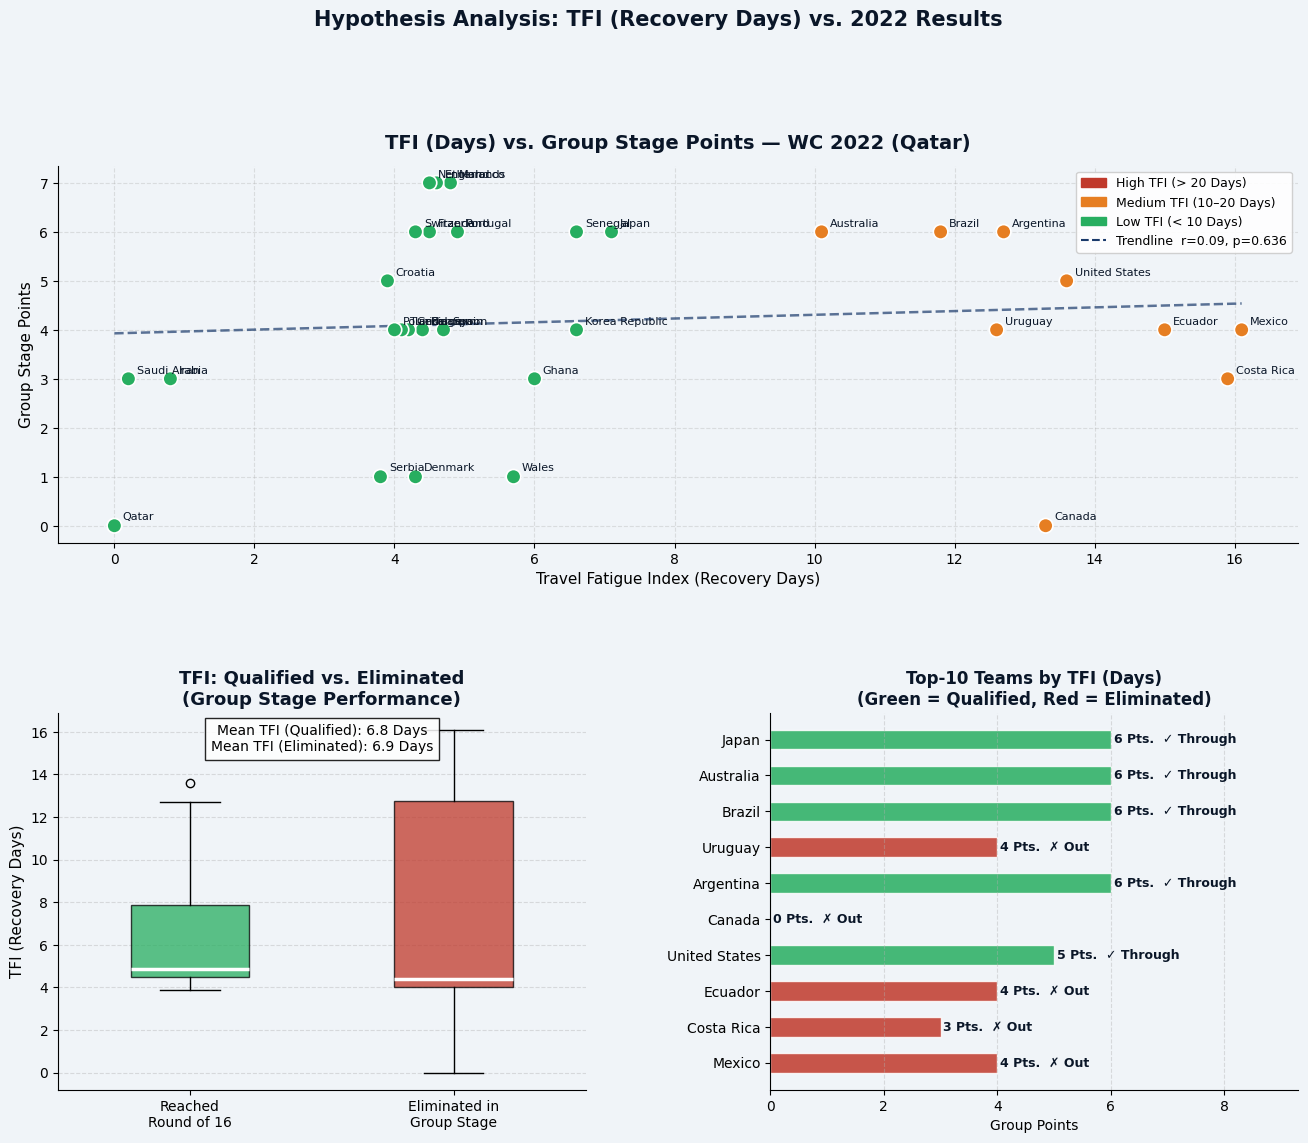

In [39]:
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#F0F4F8')
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# Color logic for data points based on TFI
dot_colors = ['#C0392B' if t >= 20 else '#E67E22' if t >= 10 else '#27AE60'
              for t in df_merged_2022['TFI_Total']]

# --- Chart 1: Scatterplot TFI vs. Points ---
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor('#F0F4F8')

ax1.scatter(df_merged_2022['TFI_Total'], df_merged_2022['group_points'],
            c=dot_colors, s=110, zorder=3, edgecolors='white', linewidth=1.2)

# Add team names as labels
for _, row in df_merged_2022.iterrows():
    ax1.annotate(row['Team'],
                 (row['TFI_Total'], row['group_points']),
                 textcoords='offset points',
                 xytext=(6, 4), fontsize=8, color='#0A1628')

# Calculate trend line (linear regression)
z = np.polyfit(df_merged_2022['TFI_Total'], df_merged_2022['group_points'], 1)
p_fit = np.poly1d(z)
x_line = np.linspace(df_merged_2022['TFI_Total'].min(), df_merged_2022['TFI_Total'].max(), 200)
ax1.plot(x_line, p_fit(x_line), '--', color='#1A3A6B', linewidth=1.8, alpha=0.7)

# Legend configuration
legend_elements = [
    mpatches.Patch(color='#C0392B', label='High TFI (> 20 Days)'),
    mpatches.Patch(color='#E67E22', label='Medium TFI (10–20 Days)'),
    mpatches.Patch(color='#27AE60', label='Low TFI (< 10 Days)'),
    plt.Line2D([0], [0], linestyle='--', color='#1A3A6B',
               label=f'Trendline  r={r1:.2f}, p={p1:.3f}'),
]
ax1.legend(handles=legend_elements, fontsize=9, framealpha=0.9, loc='upper right')
ax1.set_xlabel('Travel Fatigue Index (Recovery Days)', fontsize=11)
ax1.set_ylabel('Group Stage Points', fontsize=11)
ax1.set_title('TFI (Days) vs. Group Stage Points — WC 2022 (Qatar)',
              fontsize=14, fontweight='bold', color='#0A1628', pad=12)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(linestyle='--', alpha=0.35)

# --- Chart 2: Boxplot Qualified vs. Eliminated ---
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor('#F0F4F8')

bp = ax2.boxplot([qualified, eliminated],
                 labels=['Reached\nRound of 16', 'Eliminated in\nGroup Stage'],
                 patch_artist=True, widths=0.45,
                 medianprops=dict(color='white', linewidth=2.5))
bp['boxes'][0].set_facecolor('#27AE60'); bp['boxes'][0].set_alpha(0.75)
bp['boxes'][1].set_facecolor('#C0392B'); bp['boxes'][1].set_alpha(0.75)

# Average values in a text box
ax2.text(0.5, 0.97,
         f"Mean TFI (Qualified): {qualified.mean():.1f} Days\n"
         f"Mean TFI (Eliminated): {eliminated.mean():.1f} Days",
         transform=ax2.transAxes, ha='center', va='top', fontsize=10,
         bbox=dict(facecolor='white', alpha=0.85))
ax2.set_ylabel('TFI (Recovery Days)', fontsize=11)
ax2.set_title('TFI: Qualified vs. Eliminated\n(Group Stage Performance)',
              fontsize=13, fontweight='bold', color='#0A1628')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# --- Chart 3: Top-10 Teams by TFI Burden ---
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor('#F0F4F8')

top10 = df_merged_2022.nlargest(10, 'TFI_Total')[['Team', 'TFI_Total', 'group_points', 'qualified_knockout']].copy()
bar_c = ['#27AE60' if a == 1 else '#C0392B' for a in top10['qualified_knockout']]

ax3.barh(top10['Team'], top10['group_points'],
         color=bar_c, alpha=0.85, edgecolor='white', height=0.55)

for i, (pts, adv) in enumerate(zip(top10['group_points'], top10['qualified_knockout'])):
    status_str = "✓ Through" if adv else "✗ Out"
    ax3.text(pts + 0.05, i,
             f"{int(pts)} Pts.  {status_str}",
             va='center', fontsize=9, fontweight='bold', color='#0A1628')

ax3.set_xlabel('Group Points', fontsize=10)
ax3.set_xlim(0, top10['group_points'].max() * 1.55)
ax3.set_title('Top-10 Teams by TFI (Days)\n(Green = Qualified, Red = Eliminated)',
              fontsize=12, fontweight='bold', color='#0A1628')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='x', linestyle='--', alpha=0.4)

plt.suptitle('Hypothesis Analysis: TFI (Recovery Days) vs. 2022 Results',
             fontsize=15, fontweight='bold', color='#0A1628', y=1.01)

plt.tight_layout()
plt.show()

## Diagnostic output - dataset validation

In [40]:
print("=" * WIDTH)
print("1. TFI VALUES FOR 2026 WORLD CUP (PREDICTION)".center(WIDTH))
print("=" * WIDTH)
# Updated to English keys: Team, Distance_km, JetLag_Days, Recovery_Deficit, TFI_Total
cols_2026 = ['Team', 'Distance_km', 'JetLag_Days', 'Recovery_Deficit', 'TFI_Total']
print(df_tfi[cols_2026].head(10))

print("=" * WIDTH)
print("2. LOGISTICS DATA (AIRPORTS & REGIONS)".center(WIDTH))
print("--- Load per Airport ---".center(WIDTH))
print("=" * WIDTH)
print(airport_total.head(10))
print("\n--- Regional Load Distribution ---")
print(region_load)
print("\n--- Identified Peak Load Phases (Operational Pressure) ---")
if not df_peak.empty:
    print(df_peak.head(10))
else:
    print("No peak load phases identified.")

print("=" * WIDTH)
print("3. STATISTICAL CORRELATIONS (HISTORICAL 2022)".center(WIDTH))
print("=" * WIDTH)
# Using the previously calculated r1, p1, r2, p2, and t_stat values
print(f"Correlation TFI vs. Points:   r = {r1:.3f}, p = {p1:.3f}")
print(f"Correlation TFI vs. Goals:    r = {r2:.3f}, p = {p2:.3f}")
print(f"T-Test (Qualified vs. Out):   t = {t_stat:.3f}, p = {p_t:.3f}")
print(f"Mean TFI (Qualified):         {qualified.mean():.1f} Days")
print(f"Mean TFI (Eliminated):        {eliminated.mean():.1f} Days")

print("=" * WIDTH)
print("4. HISTORICAL TFI COMPARISON (WC 2022 TOP 10)".center(WIDTH))
print("=" * WIDTH)
# Using English keys for the historical dataframe
cols_2022 = ['Team', 'Distance_km', 'JetLag_Days', 'TFI_Total']
print(df_tfi_2022[cols_2022].head(10))

               1. TFI VALUES FOR 2026 WORLD CUP (PREDICTION)               
       Team  Distance_km  JetLag_Days  Recovery_Deficit  TFI_Total
0  DR Congo      31749.0         15.0                 0       30.9
1     Italy      23816.0         12.0                 0       23.9
2   Bolivia      19302.0          5.5                 0       15.2
3    Turkey      15889.0          5.5                 0       13.4
4   Denmark      16431.0          5.0                 0       13.2
5   Germany      13482.0          4.5                 0       11.2
6    Sweden      10820.0          3.5                 0        8.9
                   2. LOGISTICS DATA (AIRPORTS & REGIONS)                  
                          --- Load per Airport ---                         
  airport_code               city_name region_cluster  total_matches
0          DAL                  Dallas        Central              9
1          ATL                 Atlanta           East              8
2          EWR     New York/N


## Statistical interpretation of the result WC 2022

1.  Correlation (TFI VS. points)
    The correlation is negligible (r = 0.087), indicating nearly zero relationship. The p-value is 0.636 (p > 0.05), meaning the result is not statistically significant.

2. Correlation (TFI VS. Goal difference)
    Similar results are observed for goals: r = -0.041 and p = 0.823.
    This confirms that there is no correlation between travel load and scoring performance.

3. T-TEST (Qualified VS. Eliminated)
    The T-test shows no significant difference between the two groups (p = 0.937).
    The mean TFI values are almost identical, with a difference of only 0.1 days.

4. Final conclusion
    The data indicates that there was no measurable impact of TFI on results in 2022.
    This is likely due to the compact nature of the Qatar tournament (minimal travel).

### Hypothesy is not supported.
The historical data for 2022 does not confirm the fatigue-performance link, which provides a crucial baseline for the high-travel 2026 World Cup analysis.

## Export: Save the updated CSV files to the notebook directory

In [41]:
# Get the absolute path of the current directory
_out_dir = os.path.dirname(os.path.abspath('__file__'))

# Exporting dataframes to CSV
tournament_stages.to_csv(os.path.join(_out_dir, 'tournament_stages_updated.csv'), index=False, encoding='ascii')
teams.to_csv(os.path.join(_out_dir, 'teams_updated.csv'), index=False, encoding='utf-8')
matches.to_csv(os.path.join(_out_dir, 'matches_updated.csv'), index=False, encoding='ascii')
host_cities.to_csv(os.path.join(_out_dir, 'host_cities_updated.csv'), index=False, encoding='ascii')

print("Files successfully exported:")
for name in ['tournament_stages_updated.csv', 'teams_updated.csv', 'matches_updated.csv', 'host_cities_updated.csv']:
    path = os.path.join(_out_dir, name)
    print(f"   {path}")

Files successfully exported:
   /Users/mac/Documents/WB DSI/FIFAWorldCup2026project/tournament_stages_updated.csv
   /Users/mac/Documents/WB DSI/FIFAWorldCup2026project/teams_updated.csv
   /Users/mac/Documents/WB DSI/FIFAWorldCup2026project/matches_updated.csv
   /Users/mac/Documents/WB DSI/FIFAWorldCup2026project/host_cities_updated.csv
